## Load Data and Define Features

In [35]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/processed/featured_orders.csv')
df = df.dropna()

cols_to_drop = [
    'order_id', 'target', 
    'review_score', 'has_review',      
    'customer_zip_code_prefix'         
]

X = df.drop(columns=cols_to_drop, errors='ignore')
y = df['target']

categorical_cols = X.select_dtypes(include=['object']).columns
columns_to_drop_text = [col for col in categorical_cols if X[col].nunique() > 50]
X = X.drop(columns=columns_to_drop_text)

print("Data loaded, cleaned, and LEAKAGE FIXED.")

Data loaded, cleaned, and LEAKAGE FIXED.


C:\Users\USER\AppData\Local\Temp\ipykernel_10320\898038449.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


## Categorical Encoding

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Encoding
X = pd.get_dummies(X, drop_first=True)

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Encoding, Splitting, and Scaling completed.")

Encoding, Splitting, and Scaling completed.


## Setup Metrics & Plotting

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Dictionary to store results
model_performance = {}

print("Ready to train models and plot matrices.")

Ready to train models and plot matrices.


## Initialize Evaluation Dictionary

In [13]:
# Dictionary to store performance metrics of all models
model_performance = {}

print("Performance dictionary initialized.")

Performance dictionary initialized.


## Model 1 - Logistic Regression

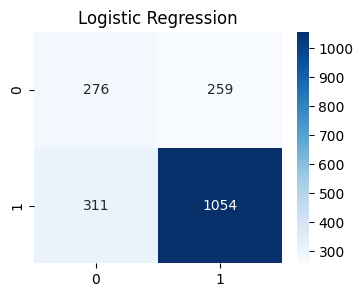

In [38]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_lr.fit(X_train_scaled, y_train)

y_pred = model_lr.predict(X_test_scaled)
y_proba = model_lr.predict_proba(X_test_scaled)[:, 1]

cm = confusion_matrix(y_test, y_pred)
model_performance["Logistic Regression"] = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall (Negative)": cm[0, 0] / (cm[0, 0] + cm[0, 1]),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression')
plt.show()

## Model 2 - Decision Tree

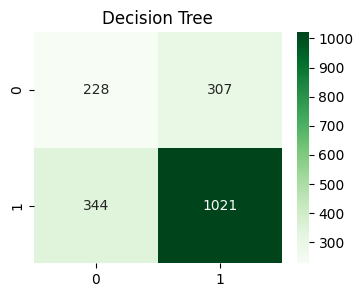

In [39]:
from sklearn.tree import DecisionTreeClassifier

# Thêm class_weight='balanced'
model_dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
model_dt.fit(X_train_scaled, y_train)

y_pred = model_dt.predict(X_test_scaled)
y_proba = model_dt.predict_proba(X_test_scaled)[:, 1]

cm = confusion_matrix(y_test, y_pred)
model_performance["Decision Tree"] = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall (Negative)": cm[0, 0] / (cm[0, 0] + cm[0, 1]),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Decision Tree')
plt.show()

## Model 3 - Random Forest

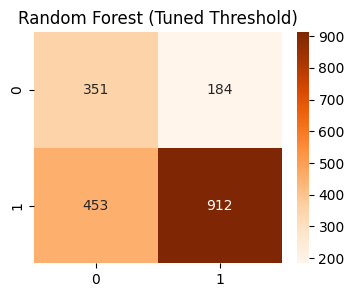

In [41]:
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

model_rf = RandomForestClassifier(random_state=42, class_weight='balanced')
model_rf.fit(X_train_scaled, y_train)

y_proba_rf = model_rf.predict_proba(X_test_scaled)[:, 1] 

THRESHOLD = 0.75
y_pred_rf = np.where(y_proba_rf >= THRESHOLD, 1, 0)

cm = confusion_matrix(y_test, y_pred_rf)
model_performance["Random Forest"] = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall (Negative)": cm[0, 0] / (cm[0, 0] + cm[0, 1]),
    "F1-Score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_proba_rf)
}

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('Random Forest (Tuned Threshold)')
plt.show()

In [24]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.6 MB/s eta 0:01:05
   ---------------------------------------- 0.8/101.7 MB 1.6 MB/s eta 0:01:05
   ---------------------------------------- 1.0/101.7 MB 1.6 MB/s eta 0:01:05
    --------------------------------------- 1.3/101.7 MB 1.5 MB/s eta 0:01:06
    --------------------------------------- 1.6/101.7 MB 1.5 MB/s eta 0:01:06
    --------------------------------------- 1.8/101.7 MB 1.5 MB/s eta 0:01:06
    --------------------------------------- 2.4/101.7 MB 1.5 MB/s eta 0:01:06
   - -------------------------------------- 2.6/101.7 MB 1.5 MB/s eta 0:01:06
   - -------------------------------------- 2.9/101.7 MB 1.5 MB/s eta 0:01:06
   - -------------------------------------- 3.1/101.7 MB 1.5 MB/s eta 0:01:05
   - -------------------------------------- 3.4/101.7 MB 1.5 MB/s eta 0:01:05


## Model 4 - XGBoost

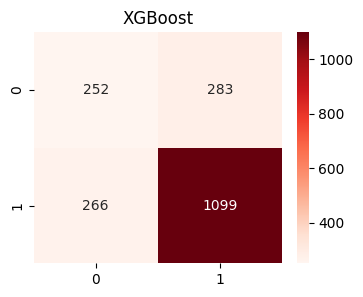

In [42]:
from xgboost import XGBClassifier

weight_ratio = sum(y_train == 0) / sum(y_train == 1)
model_xgb = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=weight_ratio)
model_xgb.fit(X_train_scaled, y_train)

y_pred = model_xgb.predict(X_test_scaled)
y_proba = model_xgb.predict_proba(X_test_scaled)[:, 1]

cm = confusion_matrix(y_test, y_pred)
model_performance["XGBoost"] = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall (Negative)": cm[0, 0] / (cm[0, 0] + cm[0, 1]),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('XGBoost')
plt.show()

## Final Model Comparison Table

In [43]:
# Convert performance metrics dictionary to a DataFrame
performance_df = pd.DataFrame(model_performance).T

# Sort models based on the crucial metric: Recall (Negative Class)
performance_df = performance_df.sort_values(by="Recall (Negative)", ascending=False)

print("--- FINAL MODEL PERFORMANCE COMPARISON ---")
display(performance_df)

--- FINAL MODEL PERFORMANCE COMPARISON ---


,Accuracy,Precision,Recall (Negative),F1-Score,ROC-AUC
Random Forest,0.664737,0.832117,0.656075,0.741162,0.713322
Logistic Regression,0.700000,0.802742,0.515888,0.787155,0.687734
XGBoost,0.711053,0.795224,0.471028,0.800146,0.679180
Decision Tree,0.657368,0.768825,0.426168,0.758262,0.587077
